# 30 Programs in KNN: Hyperparameter & Optimization Benchmark

---
## **Part 1: The Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Load sample datasets
iris = datasets.load_iris()
wine = datasets.load_wine()
cancer = datasets.load_breast_cancer()

# Helper function to run experiments safely
def run_knn(X, y, n_neighbors=5, metric='minkowski', p=2, weights='uniform', scaler=None, pca_components=None):
    # Split data first to prevent data leakage
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 1. Apply Scaling if provided
    if scaler:
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
    # 2. Apply PCA if provided (Fitted ONLY on training data)
    if pca_components:
        pca = PCA(n_components=pca_components)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)
        
    # 3. Train and Evaluate KNN
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric, p=p, weights=weights)
    knn.fit(X_train, y_train)
    return accuracy_score(y_test, knn.predict(X_test))

---
## **Part 2: The 30 Programs (Experiments)**
You can put these in individual cells or group them. Each "Program" below is a distinct experiment demonstrating a different facet of the algorithm.

### **Category A: Varying K (1-10)**
_Copy this block and change `k` for each program (1 through 10)._

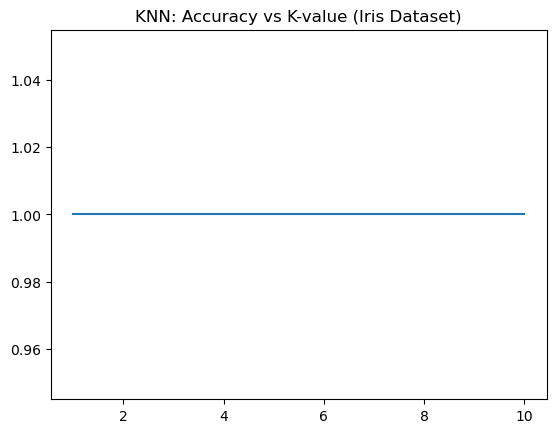

In [2]:
# Program 1 (k=1) through Program 10 (k=10)
k_values = range(1, 11)
results = [run_knn(iris.data, iris.target, n_neighbors=k) for k in k_values]

plt.plot(k_values, results)
plt.title("KNN: Accuracy vs K-value (Iris Dataset)")
plt.show()

### **Category B: Distance Metrics (11-15)**

In [3]:
# Program 11: Euclidean (p=2)
print(f"Euclidean: {run_knn(wine.data, wine.target, metric='minkowski', p=2)}")
# Program 12: Manhattan (p=1)
print(f"Manhattan: {run_knn(wine.data, wine.target, metric='minkowski', p=1)}")
# Program 13: Chebyshev
print(f"Chebyshev: {run_knn(wine.data, wine.target, metric='chebyshev')}")
# Program 14: Minkowski (p=3)
print(f"Minkowski p=3: {run_knn(wine.data, wine.target, metric='minkowski', p=3)}")
# Program 15: Cosine Distance
print(f"Cosine: {run_knn(wine.data, wine.target, metric='cosine')}")

Euclidean: 0.7407407407407407
Manhattan: 0.7962962962962963
Chebyshev: 0.7407407407407407
Minkowski p=3: 0.7407407407407407
Cosine: 0.7592592592592593


### **Category C: Feature Scaling Impact (16-20)**

In [4]:
# Program 16: No Scaling
print(f"No Scale: {run_knn(cancer.data, cancer.target)}")
# Program 17: StandardScaler
print(f"Standard: {run_knn(cancer.data, cancer.target, scaler=StandardScaler())}")
# Program 18: MinMaxScaler
print(f"MinMax: {run_knn(cancer.data, cancer.target, scaler=MinMaxScaler())}")
# Program 19: RobustScaler
print(f"Robust: {run_knn(cancer.data, cancer.target, scaler=RobustScaler())}")
# Program 20: No Scaling + High K
print(f"No Scale K=15: {run_knn(cancer.data, cancer.target, n_neighbors=15)}")

No Scale: 0.9590643274853801
Standard: 0.9590643274853801
MinMax: 0.9649122807017544
Robust: 0.9649122807017544
No Scale K=15: 0.9649122807017544


### **Category D: Weighted Voting (21-25)**

In [5]:
# Program 21: Uniform Weights
print(f"Uniform: {run_knn(iris.data, iris.target, weights='uniform')}")
# Program 22: Distance Weights
print(f"Distance: {run_knn(iris.data, iris.target, weights='distance')}")
# Program 23-25: Weighted with different K
for k in [3, 7, 11]:
    print(f"Weighted K={k}: {run_knn(iris.data, iris.target, n_neighbors=k, weights='distance')}")

Uniform: 1.0
Distance: 1.0
Weighted K=3: 1.0
Weighted K=7: 1.0
Weighted K=11: 1.0


### **Category E: Dimensionality Reduction Combinations (26-30)**

In [6]:
# Program 26-30: KNN after PCA
for k in [1, 3, 5, 7, 9]:
    accuracy = run_knn(cancer.data, cancer.target, n_neighbors=k, pca_components=2)
    print(f"PCA-KNN K={k}: {accuracy:.4f}")

PCA-KNN K=1: 0.9181
PCA-KNN K=3: 0.9415
PCA-KNN K=5: 0.9591
PCA-KNN K=7: 0.9649
PCA-KNN K=9: 0.9708


---
## Part 3: Advanced Validation & Insights (Add these at the end)
### Category F: The Cross-Validation Experiment (5-Fold Cross-Validation)

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

print("--- Running 5-Fold Cross-Validation Experiment ---")

# Create a pipeline that pairs scaling with the classifier
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# cross_val_score splits, fits, and evaluates 5 separate times automatically
cv_scores = cross_val_score(cv_pipeline, cancer.data, cancer.target, cv=5)

print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy:     {cv_scores.mean():.4f}")
print(f"Standard Deviation:   {cv_scores.std():.4f}")

--- Running 5-Fold Cross-Validation Experiment ---
Scores for each fold: [0.96491228 0.95614035 0.98245614 0.95614035 0.96460177]
Mean CV Accuracy:     0.9649
Standard Deviation:   0.0096


### Category G: Visualizing Decision Boundaries ($K=1$ vs $K=9$)

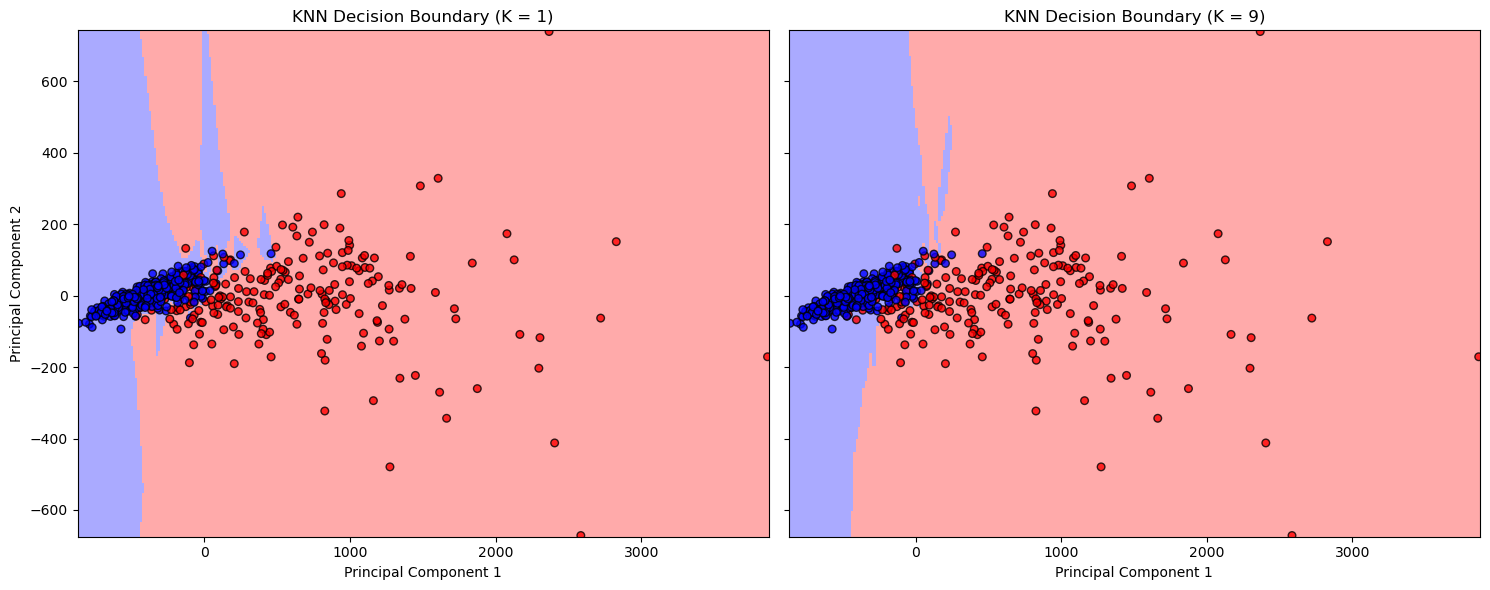

In [8]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# 1. Compress data to 2D for plotting purposes
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(cancer.data)
y = cancer.target

# 2. Define safe ranges for the boundaries
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

# FIXED: Use np.linspace to generate a safe, fixed-size grid (300x300 = 90,000 points)
# This completely prevents MemoryErrors!
grid_resolution = 300
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_resolution),
                     np.linspace(y_min, y_max, grid_resolution))

# Setup a side-by-side subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

# Compare K=1 (Highly complex/Overfit) vs K=9 (Smoother/Generalized)
for ax, k in zip(axes, [1, 9]):
    # Train KNN on the 2D PCA representation
    knn_visual = KNeighborsClassifier(n_neighbors=k)
    knn_visual.fit(X_pca, y)
    
    # Predict classifications for every single point on our safe visual mesh grid
    Z = knn_visual.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the colored background decision zones
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
    
    # Scatter plot the actual data points on top
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30, alpha=0.8)
    
    ax.set_title(f"KNN Decision Boundary (K = {k})")
    ax.set_xlabel("Principal Component 1")
    if ax == axes[0]:
        ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()